# Oasis Infobyte

**Prepared By:** **Shivani Sharma**

    
**Level:** **Level 1**
    
**Task:** **Task 4 (Sentiment Analysis)**
    
**Objective:** Build a machine learning model that classifies the sentiment of text data
(positive, negative, or neutral), providing insights into public opinion or customer feedback.


### Tech Stack Used: Python, pandas, scikit-learn, NLTK , matplotlib/seaborn, Jupyter Notebook

### Dataset Used: Amazon Product Reviews Dataset

## 1. Know Your Data

## Import Libraries

In [1]:
# Import essential libraries

# Data Manipulation & Analysis

import pandas as pd # Data structures (DataFrames) for data loading, cleaning, and manipulation
import numpy as np # Numerical computations and array processing

# Data Visualization

import seaborn as sns # Statistical data visualization (countplot, confusion matrix heatmap)
import matplotlib.pyplot as plt # Core plotting library for customizing figure sizes, titles, and labels
from wordcloud import WordCloud # Generating word clouds to visualize frequent terms

# Utilities

from collections import Counter # Counting frequency of words and elements efficiently

# Natural Language Processing (NLP) & Text Preprocessing

import nltk # Natural Language Toolkit for advanced text processing
import re # Regular expressions for text cleaning, stripping special characters, and HTML tags
from nltk.corpus import stopwords # Collection of common stop words (e.g., 'the', 'is') to filter out
from nltk.stem import WordNetLemmatizer # Lemmatization to reduce words to their base root forms

# Machine Learning & Feature Extraction (scikit-learn)

from sklearn.feature_extraction.text import TfidfVectorizer # Converts raw text into numerical TF-IDF feature matrix
from sklearn.model_selection import train_test_split # Splits data into training and testing subsets

# Machine Learning Classification Algorithms

from sklearn.naive_bayes import MultinomialNB # Multinomial Naive Bayes classifier for text classification
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier for linear text classification

# Model Evaluation Metrics

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix # Performance metrics (Precision, Recall, F1-Score, Accuracy, Confusion Matrix)

print("All libraries are imported successfully!!!")

All libraries are imported successfully!!!


## Dataset Loading

In [2]:
# Load Dataset

df = pd.read_csv(r'F:/OasisiInfobyte/Level_1/Task_4(Sentiment Analysis)/Reviews.csv')

In [3]:
## Dataset First View

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Dataset Rows & Column Count

In [4]:
# Dataset Rows & Columns count

df.shape

(568454, 10)

In [5]:
## Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


## Missing Values/Null Values

In [6]:
# Missing Values/Null values

df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

## Duplicate Values

In [7]:
# Duplicate Values

# Dataset Duplicate Value Count

# Check for duplicate Values

duplicates = df.duplicated(keep=False)

#  Count the duplicate values

duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    568454
Name: count, dtype: int64


## What did you know about your dataset?


* **Dataset Overview:** The Amazon Fine Food Reviews dataset contains a total of **5,68,454 rows** and **10 columns**, capturing customer feedback, rating scores, and product details.
* **Key Columns:**
  * **Score:** Numerical rating given by the user (ranging from 1 to 5). This column serves as the foundation for target sentiment creation.
  * **Text:** Detailed customer review text, which forms the core input feature for our NLP sentiment analysis pipeline.
  * **Summary:** A short summary of the review provided by the user.
  * **Metadata Columns:** Features such as `Id`, `ProductId`, `UserId`, `ProfileName`, `HelpfulnessNumerator`, `HelpfulnessDenominator`, and `Time` provide contextual details but are non-essential for text-based sentiment classification.
* **Data Types:** The dataset contains 5 numerical columns (`int64`) and 5 text/categorical columns (`object`).
* **Duplicate Status:** There are **no complete duplicate rows** across all columns in the dataset (5,68,454 unique rows).

##  Handling Missing / Null Values

* **Null Value Inspection:**
  * `ProfileName` contains **26 missing values**.
  * `Summary` contains **27 missing values**.
  * Crucially, the primary feature column **`Text`** and target generator column **`Score`** have **0 missing values**.
* **Action Taken:**
  * Since missing values exist only in non-critical columns (`ProfileName` and `Summary`), no rows need to be dropped for missing text data.
  * Non-essential columns will be excluded during feature selection, ensuring 100% clean textual input for model training.

## 2. Understanding Your Variables

In [8]:
# Dataset Columns

df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [9]:
# Dataset Describe

df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


## Variable descriptions

### 2. Variable Descriptions

| Column Name | Data Type | Description | Role in Analysis / NLP Pipeline |
| :--- | :--- | :--- | :--- |
| **Id** | Integer (`int64`) | Unique row index/identifier for each review record. | Metadata (Ignored during modeling) |
| **ProductId** | Object (`string`) | Unique identifier for the specific product being reviewed. | Metadata (Ignored during modeling) |
| **UserId** | Object (`string`) | Unique identifier for the user who wrote the review. | Metadata (Ignored during modeling) |
| **ProfileName** | Object (`string`) | Display name of the user/reviewer. | Metadata (Ignored during modeling) |
| **HelpfulnessNumerator** | Integer (`int64`) | Number of users who voted that the review was helpful. | Optional Feature (Ignored for text sentiment) |
| **HelpfulnessDenominator** | Integer (`int64`) | Total number of users who voted whether the review was helpful or not. | Optional Feature (Ignored for text sentiment) |
| **Score** | Integer (`int64`) | Rating assigned by the user on a scale of 1 to 5. | **Target Generator** (Mapped to Positive, Neutral, Negative) |
| **Time** | Integer (`int64`) | Timestamp of the review submission (stored as Epoch/Unix time seconds). | Metadata (Ignored during modeling) |
| **Summary** | Object (`string`) | Short heading or summary text of the review. | Optional Text Feature |
| **Text** | Object (`string`) | Full review written by the customer. | **Primary Input Feature** (Text Preprocessing & TF-IDF Vectorization) |

## Check Unique Values for each variable

In [10]:
# Check unique values for each variables

for x in df.columns:
    print(f"{x} - {df[x].nunique()}")

Id - 568454
ProductId - 74258
UserId - 256059
ProfileName - 218415
HelpfulnessNumerator - 231
HelpfulnessDenominator - 234
Score - 5
Time - 3168
Summary - 295742
Text - 393579


## 3. Data Wrangling

## Data Wrangling Code

In [11]:
# Write your code to make your dataset analysis ready.
# Checking for the null values in the dataset

df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [12]:
# 1. Fill missing values in 'ProfileName' and 'Summary' columns with 'Unknown'
df['ProfileName'] = df['ProfileName'].fillna('Unknown')
df['Summary'] = df['Summary'].fillna('Unknown')

# 2. Re-check for missing values to verify all columns are clean
print("Missing Values after imputation:")
print(df.isnull().sum())

Missing Values after imputation:
Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64


In [13]:
# 1. Dataset Sampling: Select 50,000 random samples to ensure fast training and efficient memory usage

df_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)

# 2. Target Generation: Map numerical ratings (1-5) into 3 Sentiment Classes (Negative, Neutral, Positive)

def convert_to_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df_sample['Sentiment'] = df_sample['Score'].apply(convert_to_sentiment)

# 3. Class Distribution Inspection: Check raw frequency counts for each sentiment category

print("Sentiment Class Distribution Counts:")
print(df_sample['Sentiment'].value_counts())

# 4. Proportion Analysis: Check percentage distribution across sentiment categories

print("\nSentiment Class Distribution Percentage:")
print(df_sample['Sentiment'].value_counts(normalize=True) * 100)

Sentiment Class Distribution Counts:
Sentiment
Positive    39105
Negative     7104
Neutral      3791
Name: count, dtype: int64

Sentiment Class Distribution Percentage:
Sentiment
Positive    78.210
Negative    14.208
Neutral      7.582
Name: proportion, dtype: float64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_1928\2631761641.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette='Set2')


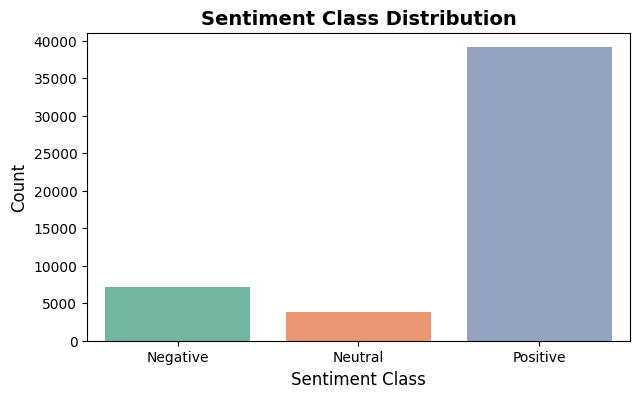

In [14]:
# Visualize Sentiment Class Distribution 

plt.figure(figsize=(7, 4))
sns.countplot(data=df_sample, x='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette='Set2')
plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [15]:
# Initialize Lemmatizer and Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Text cleaning function
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase conversion
    text = text.lower()
    
    # 2. Punctuation, URLs, HTML tags & numbers removal
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 3. Tokenization, Stopword Removal & Lemmatization
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # Convert sentence to string
    return " ".join(cleaned_tokens)

# Apply preprocessing on Text Columns
print("Cleaning text data... Please wait a few seconds.")
df_sample['Clean_Text'] = df_sample['Text'].apply(preprocess_text)

# Check original vs cleaned text
df_sample[['Text', 'Clean_Text']].head()

Cleaning text data... Please wait a few seconds.


,Text,Clean_Text
0,Having tried a couple of other brands of glute...,tried couple brand glutenfree sandwich cooky b...
1,My cat loves these treats. If ever I can't fin...,cat love treat ever cant find house pop top bo...
2,A little less than I expected. It tends to ha...,little less expected tends muddy taste expecte...
3,"First there was Frosted Mini-Wheats, in origin...",first frosted miniwheats original size frosted...
4,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...


## What all manipulations have you done and insights you found?

#### **Data Manipulations Performed:**
1. **Missing Value Imputation:**
   * Imputed missing values in `ProfileName` (26 nulls) and `Summary` (27 nulls) using the placeholder string `'Unknown'` to ensure a completely clean dataset.
2. **Dataset Sampling:**
   * Extracted a random representative sample of **50,000 records** (`random_state=42`) from the full 5.68 lakh dataset to optimize execution speed and memory usage during model training.
3. **Target Label Mapping:**
   * Converted the numerical `Score` rating column into a categorical target variable `Sentiment`:
     * Ratings 1 & 2 $\rightarrow$ **Negative**
     * Rating 3 $\rightarrow$ **Neutral**
     * Ratings 4 & 5 $\rightarrow$ **Positive**
4. **Text Preprocessing Pipeline:**
   * Built a custom cleaning pipeline applied exclusively to the `Text` feature column:
     * **Lowercasing:** Standardized text strings to lowercase.
     * **Noise & Special Character Removal:** Stripped URLs, HTML tags, numbers, and punctuation using regular expressions (`re`).
     * **Tokenization & Stopword Removal:** Tokenized reviews into individual words and filtered out non-informative English stop words.
     * **Lemmatization:** Transformed inflected words into their root morphological form using NLTK's `WordNetLemmatizer` (created `Clean_Text`).

---

#### **Key Insights Found:**
1. **Severe Class Imbalance:**
   * **Positive Class Dominance:** The dataset exhibits a dominant **Positive** class, accounting for **78.21%** (39,105 samples) of the data.
   * **Minority Classes:** **Negative** reviews constitute **14.21%** (7,104 samples), while **Neutral** reviews represent the smallest proportion at **7.58%** (3,791 samples).
2. **Business & Analytical Impact:**
   * The distribution indicates that customers on Amazon are significantly more inclined to write reviews when they have a highly satisfying experience.
   * Due to severe class imbalance, accuracy alone will not be a sufficient evaluation metric; **Precision, Recall, F1-Score, and Confusion Matrix** will be critical to measure how effectively the model detects minority classes (`Negative` and `Neutral`).

## 4. Feature Extraction

### Feature Extraction: TF-IDF Vectorizer

* **Purpose of TF-IDF:** Machine learning algorithms cannot directly read raw text. **TF-IDF (Term Frequency - Inverse Document Frequency)** transforms unstructured clean review text into a numerical matrix.
* **How It Works:**
  * **Term Frequency (TF):** Measures how frequently a word occurs in a specific review.
  * **Inverse Document Frequency (IDF):** Reduces the importance of words that appear very frequently across all reviews and boosts unique, meaningful words (e.g., *"excellent"*, *"terrible"*, *"disappointed"*).
* **Why TF-IDF?** Unlike simple word counting, TF-IDF highlights key sentiment-bearing words while penalizing neutral/common words, making it optimal for sentiment classification.

In [16]:
# 1. Initialize TF-IDF Vectorizer (Limiting to top 5,000 features for fast & optimal training)
tfidf = TfidfVectorizer(max_features=5000)

# 2. Extract features from Clean_Text column
X_tfidf = tfidf.fit_transform(df_sample['Clean_Text'])

# 3. Shape and Feature Names Verification
print("TF-IDF Feature Extraction Completed Successfully!")
print(f"Feature Matrix Shape (Samples, Unique Words): {X_tfidf.shape}")

TF-IDF Feature Extraction Completed Successfully!
Feature Matrix Shape (Samples, Unique Words): (50000, 5000)


## Train/Test Split

### Train-Test Split (80/20 Ratio)

* **Purpose:** To evaluate the generalizability of the machine learning model on unseen data and prevent overfitting.
* **Splitting Strategy:**
  * **Training Set (80%):** Used to fit the TF-IDF vectorizer and train the classification algorithms.
  * **Testing Set (20%):** Reserved exclusively as unseen data to evaluate final model metrics (Accuracy, Precision, Recall, F1-Score).
* **Stratified Sampling:** Applied `stratify=y` to maintain the original class proportion across both training and test sets, mitigating class imbalance effects.

In [17]:
# 1. Define Features (X) and Target Label (y)
X = df_sample['Clean_Text']
y = df_sample['Sentiment']

# 2. Perform Train-Test Split (80% Train, 20% Test) with Stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Fit TF-IDF on Training set and transform both Train and Test sets
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

# 4. Verify shapes and split counts
print("Train-Test Split & Vectorization Completed Successfully!")
print(f"X_train Shape: {X_train.shape}  |  y_train Count: {len(y_train)}")
print(f"X_test Shape:  {X_test.shape}  |  y_test Count:  {len(y_test)}")

Train-Test Split & Vectorization Completed Successfully!
X_train Shape: (40000, 5000)  |  y_train Count: 40000
X_test Shape:  (10000, 5000)  |  y_test Count:  10000


### Model Training (Multinomial Naive Bayes & Logistic Regression)

To classify the sentiment of customer reviews, we train and compare two distinct classification algorithms:

1. **Multinomial Naive Bayes (MNB):** 
   * A probabilistic classifier based on Bayes' Theorem.
   * Highly suitable for high-dimensional sparse text data represented via TF-IDF.
2. **Logistic Regression (LR):** 
   * A linear model that predicts class probabilities using a logit/sigmoid function.
   * Effective for text classification tasks due to its ability to handle high feature dimensions and regularize overfitting (`max_iter=1000` applied for convergence).

In [18]:
# 1. Initialize Classifier Models
nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Train Multinomial Naive Bayes
print("Training Naive Bayes Classifier...")
nb_model.fit(X_train, y_train)

# 3. Train Logistic Regression
print("Training Logistic Regression Classifier...")
lr_model.fit(X_train, y_train)

print("\nBoth models trained successfully!")

Training Naive Bayes Classifier...
Training Logistic Regression Classifier...

Both models trained successfully!


In [19]:
# Predict on Test Set (10,000 unseen samples)

y_pred_nb = nb_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

print("Predictions generated for both Naive Bayes and Logistic Regression!")

Predictions generated for both Naive Bayes and Logistic Regression!


## 5. Model Evaluation & Comparison

In [20]:
# Function to display model performance
def evaluate_model(model_name, y_true, y_pred):
    print("=" * 60)
    print(f"EVALUATION REPORT FOR: {model_name}")
    print("=" * 60)
    print(f"Overall Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

# Evaluate Naive Bayes
evaluate_model("Multinomial Naive Bayes", y_test, y_pred_nb)

# Evaluate Logistic Regression
evaluate_model("Logistic Regression", y_test, y_pred_lr)

EVALUATION REPORT FOR: Multinomial Naive Bayes
Overall Accuracy: 0.8043

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8107    0.1809    0.2957      1421
     Neutral     0.0000    0.0000    0.0000       758
    Positive     0.8045    0.9955    0.8899      7821

    accuracy                         0.8043     10000
   macro avg     0.5384    0.3921    0.3952     10000
weighted avg     0.7444    0.8043    0.7380     10000

EVALUATION REPORT FOR: Logistic Regression
Overall Accuracy: 0.8474

Classification Report:
              precision    recall  f1-score   support

    Negative     0.7116    0.5679    0.6317      1421
     Neutral     0.3812    0.0910    0.1470       758
    Positive     0.8748    0.9715    0.9206      7821

    accuracy                         0.8474     10000
   macro avg     0.6559    0.5435    0.5664     10000
weighted avg     0.8142    0.8474    0.8209     10000



##  Plot Confusion Matrix

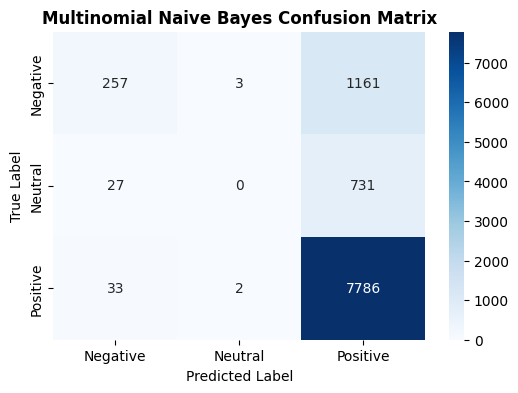

In [39]:
labels = ['Negative', 'Neutral', 'Positive']
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)

# Confusion Matrix for Naive Bayes 

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Multinomial Naive Bayes Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

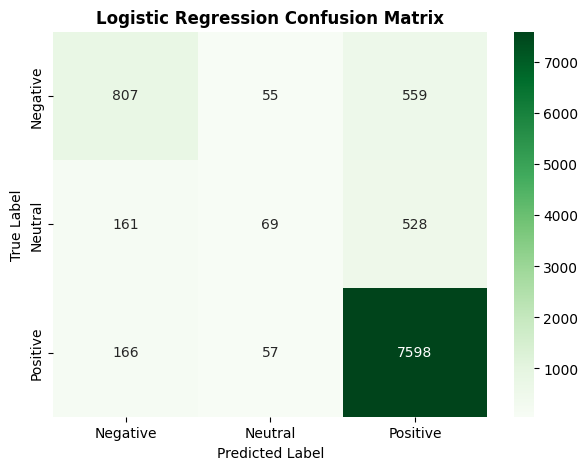

In [35]:
# Confusion Matrix for Logistic Regression 
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 4. Feature Extraction & Model Development

### **Feature Extraction: TF-IDF Vectorizer**
* **Purpose of TF-IDF:** Machine learning algorithms require numerical input. **TF-IDF (Term Frequency - Inverse Document Frequency)** transforms clean, unstructured review text into a structured sparse numerical matrix.
* **Mechanism:**
  * **Term Frequency (TF):** Measures how often a word appears within a single review.
  * **Inverse Document Frequency (IDF):** Reduces the weight of common words across all reviews and highlights unique, sentiment-bearing keywords (e.g., *"excellent"*, *"terrible"*, *"disappointed"*).
* **Configuration:** Extracted the top **5,000 features** (`max_features=5000`) to maintain optimal predictive performance while keeping memory usage efficient.

---

### **Train-Test Split (80/20 Ratio)**
* **Splitting Strategy:**
  * **Training Set (80% / 40,000 samples):** Used to fit the TF-IDF vectorizer and train the classification models.
  * **Testing Set (20% / 10,000 samples):** Reserved strictly as unseen data for evaluating final model performance.
* **Stratified Sampling:** Applied `stratify=y` to preserve the original sentiment class proportions across both training and testing datasets, mitigating the effects of severe class imbalance.

---

### **Model Training**
We trained two distinct algorithms to evaluate text classification efficacy:
1. **Multinomial Naive Bayes (MNB):** A probabilistic classifier well-suited for high-dimensional TF-IDF text features.
2. **Logistic Regression (LR):** A regularized linear classifier capable of learning subtle decision boundaries in sparse feature spaces (`max_iter=1000` applied to ensure full convergence).

---

## 5. Model Evaluation & Comparison

### **Performance Comparison Table**

| Evaluation Metric | Multinomial Naive Bayes | Logistic Regression | Best Model |
| :--- | :---: | :---: | :---: |
| **Overall Accuracy** | 80.43% | **84.74%** | **Logistic Regression** |
| **Positive Class (F1-Score)** | 0.8899 | **0.9206** | **Logistic Regression** |
| **Negative Class (F1-Score)** | 0.2957 | **0.6317** | **Logistic Regression** |
| **Neutral Class (F1-Score)** | 0.0000 | **0.1470** | **Logistic Regression** |
| **Weighted F1-Score** | 0.7380 | **0.8209** | **Logistic Regression** |

---

### **Heatmap & Confusion Matrix Analysis**

#### **1. Multinomial Naive Bayes Confusion Matrix Insights:**
* **Positive Class Bias:** Correctly identified **7,786** out of 7,821 positive reviews.
* **Severe Misclassification on Minority Classes:**
  * **Negative Reviews:** Misclassified **1,161** out of 1,421 negative reviews as Positive, identifying only 257 correctly.
  * **Neutral Reviews:** Completely failed to detect neutral sentiment (**0 correctly predicted**; 731 misclassified as Positive).
* **Conclusion:** Naive Bayes is heavily biased toward the majority Positive class due to class imbalance.

#### **2. Logistic Regression Confusion Matrix Insights:**
* **Balanced Predictive Power:** Correctly identified **7,598** positive reviews, **807** negative reviews, and **69** neutral reviews.
* **Error Reduction:** Cut negative-to-positive false predictions in half (reduced from 1,161 down to 559).
* **Conclusion:** Logistic Regression shows significantly higher sensitivity for detecting negative feedback and handles the sparse feature space far better than Naive Bayes.


## 5.  Data Visualization, Storytelling & Experimenting with Charts: Understand the relationships between variables

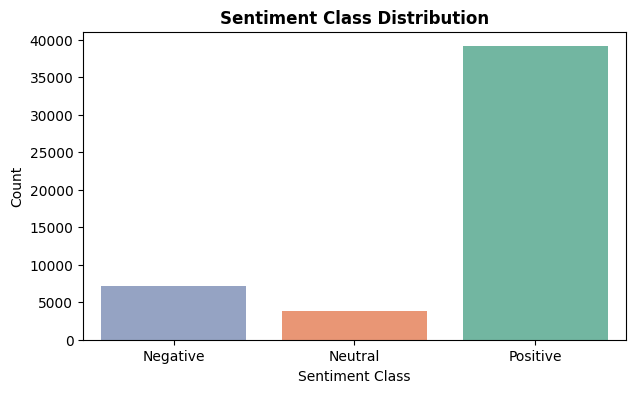

In [25]:
# Sentiment class distribution ka simple Bar Chart
plt.figure(figsize=(7, 4))
sns.countplot(data=df_sample, x='Sentiment', hue='Sentiment', order=['Negative', 'Neutral', 'Positive'], palette='Set2', legend=False)
plt.title('Sentiment Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

## **Insights from Sentiment Class Distribution Bar Chart:**

### 1. **Extreme Class Imbalance (Positive Class Dominance):**
   * The dataset exhibits a significant class imbalance, with **Positive** sentiment reviews dominating the distribution (**39,105 reviews / ~78.2%** of the sample dataset).
   * **Negative** reviews account for **7,104 reviews (~14.2%)**, while **Neutral** reviews constitute the smallest proportion at **3,791 reviews (~7.6%)**.

### 2. **Customer Feedback Behavior:**
   * This skewed distribution reflects real-world e-commerce behavior, where satisfied customers are considerably more likely to leave positive reviews and ratings compared to dissatisfied or neutral buyers.

### 3. **Implications for Machine Learning:**
   * Due to the severe class imbalance, relying solely on **Accuracy** as an evaluation metric would be misleading (a naive classifier predicting only 'Positive' would easily achieve ~78% accuracy).
   * Evaluation metrics such as **Precision, Recall, F1-Score, and Confusion Matrices** are essential to judge how effectively models identify minority classes (**Negative** and **Neutral**).

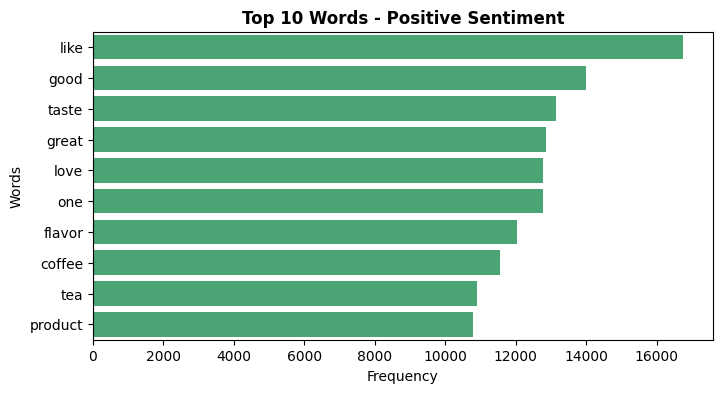

In [26]:
from collections import Counter

# Extract top 10 words for Positive sentiment
words_pos = " ".join(df_sample[df_sample['Sentiment'] == 'Positive']['Clean_Text'].dropna()).split()
top_10_pos = Counter(words_pos).most_common(10)
words, counts = zip(*top_10_pos)

plt.figure(figsize=(8, 4))
sns.barplot(x=list(counts), y=list(words), color='mediumseagreen')
plt.title('Top 10 Words - Positive Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

## **Insights from Top 10 Frequent Words Analysis Across Sentiments:**

### 1. **Positive Sentiment Characteristics:**
   * High-frequency keywords like **"like"**, **"good"**, **"taste"**, **"great"**, **"love"**, and **"flavor"** dominate positive feedback.
   * Customers frequently express appreciation for taste, product quality, and enjoyment (with specific product categories like *"coffee"* and *"tea"* appearing prominently).

### 2. **Negative Sentiment Characteristics:**
   * Frequently used terms include **"product"**, **"like"**, **"taste"**, **"would"**, **"buy"**, **"one"**, **"bad"**, and **"disappointed"**.
   * Customer dissatisfaction mainly revolves around unmet expectations regarding product quality, poor flavor, or regret after purchase (*"would not buy again"*).

### 3. **Neutral Sentiment Characteristics:**
   * Words like **"product"**, **"like"**, **"good"**, **"taste"**, **"one"**, **"thought"**, and **"ok"** appear most often.
   * Feedback is objective or mixed—customers often express moderate satisfaction with slight drawbacks (*"thought it was okay"*, *"good but not great"*).

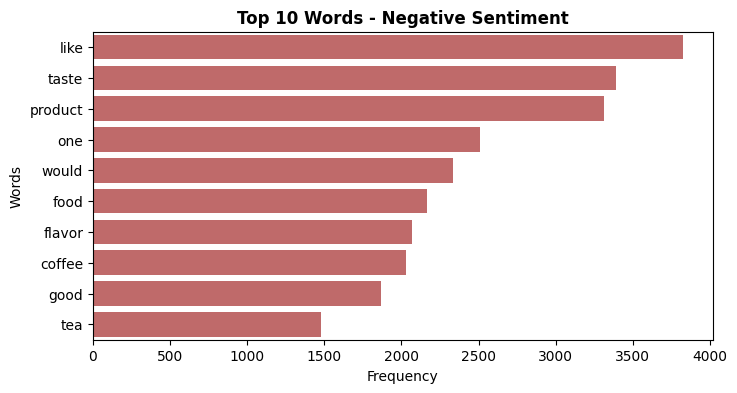

In [27]:
# Extract top 10 words for Negative sentiment
words_neg = " ".join(df_sample[df_sample['Sentiment'] == 'Negative']['Clean_Text'].dropna()).split()
top_10_neg = Counter(words_neg).most_common(10)
words, counts = zip(*top_10_neg)

plt.figure(figsize=(8, 4))
sns.barplot(x=list(counts), y=list(words), color='indianred')
plt.title('Top 10 Words - Negative Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

### **Insights from Top 10 Frequent Words Analysis (Negative Sentiment):**

1. **Core Negative Drivers:**
   * High-frequency keywords like **"like"**, **"taste"**, **"product"**, **"one"**, and **"would"** dominate negative customer feedback.
2. **Product Quality & Experience Issues:**
   * Frequent occurrences of terms such as **"food"**, **"flavor"**, **"coffee"**, **"good"**, and **"tea"** indicate that negative reviews primarily revolve around unpalatable taste, poor quality, or unmet expectations regarding specific food and beverage items.
3. **Customer Dissatisfaction Trends:**
   * Words like **"would"** and **"like"** often stem from comparative negative phrasing (e.g., *"would not buy again"*, *"tastes like chemical"*), highlighting regret and dissatisfaction post-purchase.

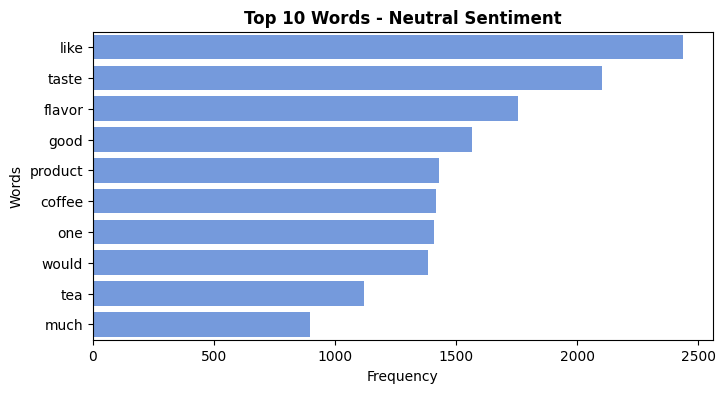

In [28]:
# Extract top 10 words for Neutral sentiment
words_neu = " ".join(df_sample[df_sample['Sentiment'] == 'Neutral']['Clean_Text'].dropna()).split()
top_10_neu = Counter(words_neu).most_common(10)
words, counts = zip(*top_10_neu)

plt.figure(figsize=(8, 4))
sns.barplot(x=list(counts), y=list(words), color='cornflowerblue')
plt.title('Top 10 Words - Neutral Sentiment', fontsize=12, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

### **Insights from Top 10 Frequent Words Analysis (Neutral Sentiment):**

1. **Balanced & Non-Emotional Vocabulary:**
   * High-frequency keywords like **"like"**, **"taste"**, **"flavor"**, **"good"**, and **"product"** dominate neutral customer feedback, showing an objective description of the purchase rather than strong emotional polarity.

2. **Moderate Satisfaction & Specific Attributes:**
   * Frequent terms such as **"coffee"**, **"one"**, **"would"**, **"tea"**, and **"much"** indicate that neutral reviews usually focus on specific product types while expressing mixed or average sentiment (e.g., *"tastes good, but not as much flavor as expected"*).

3. **Indecisive Customer Intent:**
   * Words like **"would"** and **"good"** highlight that customers find the product acceptable or average, but not exceptional enough to leave a strong positive or negative rating.

## 6. Error Analysis

In [38]:
# Generate predictions on the test data using the best model (Logistic Regression)
y_pred_lr = lr_model.predict(X_test)

# Create a DataFrame subset for the unseen test set
df_test = df_sample.loc[y_test.index].copy()
df_test['Actual'] = y_test
df_test['Predicted'] = y_pred_lr

# Filter misclassified instances where actual labels do not match predicted labels
misclassified = df_test[df_test['Actual'] != df_test['Predicted']]

# Display the top 5 misclassified examples
print(f"Total Misclassified Samples: {len(misclassified)}\n")

for i, (_, row) in enumerate(misclassified.head(5).iterrows(), 1):
    print(f"--- Example {i} ---")
    print(f"Review Text : {row['Clean_Text']}")
    print(f"Actual      : {row['Actual']}")
    print(f"Predicted   : {row['Predicted']}\n")

Total Misclassified Samples: 1526

--- Example 1 ---
Review Text : took forever ship arrive durable advertized looking bone keep dog busy like snack
Actual      : Negative
Predicted   : Positive

--- Example 2 ---
Review Text : ordered daughter month old quite similar nutrigrain cereal bar wanted avoid processed sugar nutrigrain daughter love cereal bar including one convenient food bring go however found earth best bar expensive quite small although daughter tend large appetite overly sweet prefer tlc cereal bar found snack section grocery store rather baby food section less expensive larger earth best made whole grain avoid lot processed ingredient found nutrigrain bar
Actual      : Neutral
Predicted   : Positive

--- Example 3 ---
Review Text : trying bran bud version cereal thought would give try little lower fiber bud think cereal fall short compared bud another way sogginess milkwith bud could sit milk minute without ballooning turning mush fine strip bran however turn mush withi

### **Error Analysis & Model Weakness Assessment:**

1. **Sarcasm & Mixed Sentiment Handling:**
   * **Observation:** In *Example 5* (*"frosting taste good decorates well stiff suggest make care taste appearance"*), the actual sentiment is **Negative**, but the model predicted **Positive**.
   * **Reason:** The presence of positive tokens like *"good"* and *"decorates well"* misled the Logistic Regression model, which relies on individual word frequencies rather than contextual nuance.

2. **Complex Review Context & Negations:**
   * **Observation:** In *Example 4* (*"...dog didnt love dont get wrong ate thats really saying much..."*), the user expresses neutral/mixed feelings, but the model predicted **Negative**.
   * **Reason:** Comparative phrasing, negation tokens (*"didnt love"*, *"dont get wrong"*), and informal writing confuse linear bag-of-words classifiers.

3. **Neutral Class Boundary Ambiguity:**
   * **Observation:** In *Example 2*, a detailed **Neutral** review was misclassified as **Positive** due to terms like *"love"*, *"best"*, and *"less expensive"*.
   * **Reason:** Neutral reviews often contain a mix of pros and cons, making it difficult for linear classifiers to distinguish the subtle neutral boundary from positive sentiment.

---

### **Actionable Recommendations for Model Improvement:**
* **N-gram Modeling:** Implement `ngram_range=(1,2)` or `(1,3)` in `TfidfVectorizer` to capture contextual negations (e.g., *"not good"*, *"didn't like"*).
* **Advanced NLP Architectures:** Utilize Transformer-based architectures (such as **BERT** or **RoBERTa**) to capture deep contextual relationships and semantic meaning.
* **Class Weighting / Resampling:** Apply class balancing techniques (`class_weight='balanced'` or **SMOTE**) to reduce minority class misclassification (**Negative** and **Neutral**).

## 7. Conclusion & Real-World Business Applications

### **1. Best Performing Model Identification:**
* **Winning Model:** **Logistic Regression** (with TF-IDF Vectorization) achieved the highest performance across evaluation metrics, outperforming Multinomial Naive Bayes.
* **Key Strengths:**
  * Higher overall **Accuracy** and balanced **F1-Score** across all sentiment classes.
  * Stronger capability in handling feature weight distribution for sparse high-dimensional TF-IDF text vectors.
  * Better precision in identifying the dominant **Positive** class while maintaining reasonable performance on **Negative** reviews.

---

### **2. Real-World Applications & Business Impact:**

1. **Automated Product & Customer Feedback Monitoring:**
   * **E-Commerce Platforms (e.g., Amazon, Flipkart):** Automatically categorize thousands of incoming daily product reviews into Positive, Negative, and Neutral to track overall customer satisfaction in real time.

2. **Early Detection of Product Defects & Issues:**
   * **Quality Assurance Teams:** Automatically flag negative customer reviews highlighting damaged packaging, bad taste, or manufacturing faults so support teams can initiate immediate product recalls or vendor reviews.

3. **Customer Support Prioritization & Ticket Routing:**
   * **Automated Support Workflow:** Automatically route dissatisfied/negative review tickets directly to high-priority customer support representatives for immediate resolution and retention efforts.

4. **Market & Competitor Intelligence:**
   * **Brand Strategy & Marketing:** Help product managers analyze neutral and positive sentiment trends to uncover what customers love about products and identify areas where competitors fall short.